In [1]:
import os
import glob
import pickle
import warnings
import sys
sys.path.append(os.path.abspath('..'))

import scipy
warnings.filterwarnings('ignore')
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Utils.bad_channels import NoisyChannels

from Utils.download import read_raws, load_signal
from Utils.LSTM_net import CNN_LSTM_Model
from Utils.train import  eval, data_train
from sklearn.model_selection import train_test_split

import mne
import torch
from pyprep.prep_pipeline import PrepPipeline
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(0)
import psutil
import platform
 
print("OS:", platform.system(), platform.release())
print("Python:", platform.python_version())
print("CPU:", platform.processor())
print("CPU cores:", psutil.cpu_count(logical=True))
ram = psutil.virtual_memory().total / (1024**3)
print("RAM:", round(ram,2), "GB")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)


else:
    print("GPU: Not available")

OS: Windows 10
Python: 3.11.6
CPU: Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
CPU cores: 16
RAM: 31.71 GB
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA: 12.1


In [58]:
model=CNN_LSTM_Model(num_classes=2, cnn_out=64, lstm_hidden=64, lstm_layers=2, conv_2d_layer=64, dropout_layer=0.2, dropout_lstm=0.2).to(device)
model.load_state_dict(torch.load("C:/Users\THIN\OneDrive - Escuela Tecnologica Instituto Tecnico Central\Proyecto_cerebro\MAPI\Results\h_32_36_40_44_win_Good\model_lstm_h_32_36_40_44.pt"))

<All keys matched successfully>

In [36]:
# Poor
ANODE = [
    'Fp1', 'F3', 'C3', 'P3',  # Cadena Parasagital Izquierda
    'Fp2', 'F4', 'C4', 'P4',  # Cadena Parasagital Derecha
    'F7', 'T3', 'T5',         # Cadena Temporal Izquierda
    'F8', 'T4', 'T6',         # Cadena Temporal Derecha
    'Fz', 'Cz'          # Cadena Central (opcional)
]
CATHODE = [
    'F3', 'C3', 'P3', 'O1',   # Cadena Parasagital Izquierda
    'F4', 'C4', 'P4', 'O2',   # Cadena Parasagital Derecha
    'T3', 'T5', 'O1',         # Cadena Temporal Izquierda
    'T4', 'T6', 'O2',         # Cadena Temporal Derecha
    'Cz', 'Pz',          # Cadena Central (opcional)
]
CH_NAMES = [f'{a}-{c}' for a, c in zip(ANODE, CATHODE)]

channels=['Fp1', 'Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']
channels_dif=['Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F7-T3', 'T3-T5', 'T5-O1', 'F8-T4', 'T4-T6', 'T6-O2', 'Fz-Cz', 'Cz-Pz']
path_demographic="../d/data_patients.csv"

### Data base demographic
df=pd.read_csv(path_demographic, sep=";" )
df["numeric_outcome"]=df["Outcome"].map({"Good": 1, "Poor": 0})
df.reset_index(drop=True, inplace=True)
df.head()

,Id_Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC,numeric_outcome
0,284,A,53.0,Male,NaN,True,True,33.0,Good,1,1
1,286,F,85.0,Female,7.0,False,False,NaN,Good,1,1
2,296,A,48.0,Male,NaN,True,True,36.0,Good,1,1
3,299,A,45.0,Male,NaN,True,True,33.0,Good,1,1
4,303,D,51.0,Male,24.0,True,True,33.0,Good,1,1


In [67]:
times=[32,36, 40, 44]

Raws=[]
Patients= []
Hours=[]
df_demog=pd.DataFrame()
for t in times:
    path_files=f"C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/raw_tif/t180_h{t}/"
    print(f"/t180_h{t}/")
    raw_list, patients= read_raws(path_files=path_files, time_taken=180, del_files=True)
    patients=[int(p) for p in patients]
    Raws+=raw_list
    Patients+=patients
    aux_df=df[df["Id_Patient"].isin(patients)]
    aux_df["Hour"]=t
    df_demog=pd.concat([df_demog, aux_df], ignore_index=True)
    

/t180_h32/
Opening raw data file C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/raw_tif/t180_h32/patient_0284.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/raw_tif/t180_h32/patient_0286.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/raw_tif/t180_h32/patient_0299.fif...
    Range : 0 ... 23039 =      0.000 ...   179.992 secs
Ready.
Reading 0 ... 23039  =      0.000 ...   179.992 secs...
Opening raw data file C:/Users/THIN/OneDrive - Escuela Tecnologica Instituto Tecnico Central/Proyecto_cerebro/Code/raw_tif/t180_h32/patient_0303.fif...
    Range : 0 ... 23039 

In [68]:
df_poor=df_demog[(df_demog["numeric_outcome"]==0)]# &(df_demog["CPC"]>=4)]
patients_poor=df_poor["Id_Patient"].values

df_good=df_demog[(df_demog["numeric_outcome"]==1)]# &(df_demog["CPC"]<2)]
patients_good=df_good["Id_Patient"].values

In [99]:
aux_raw

,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
0,0.007614,0.005104,0.004083,-0.006724,0.002714,-0.005953,0.001400,-0.002544,0.000670,-0.000622,0.001073,-0.003264,-0.000112,-0.000970,-0.000159,-0.002137,0.000174,-0.000208,0.000036
1,0.003196,-0.001251,-0.000829,-0.004742,-0.001407,-0.003720,0.000732,-0.000961,0.004975,0.000844,0.002641,0.001736,0.002464,-0.002544,0.004696,0.000474,-0.003023,-0.004711,-0.001595
2,-0.003345,-0.001947,-0.006066,0.003106,-0.005204,0.001385,-0.002076,0.000325,0.002200,0.001552,0.000322,0.006458,0.001088,0.000254,0.004780,0.003432,-0.002537,-0.003586,-0.002678
3,0.000614,0.003572,-0.001783,0.005286,-0.003536,0.001194,-0.004476,-0.002533,-0.004355,-0.000691,0.000942,0.007015,-0.001734,0.002765,0.000465,0.002851,0.001152,-0.001277,-0.004320
4,0.006040,0.006534,0.002387,0.006030,-0.002083,0.000860,-0.005571,-0.005014,-0.008554,-0.003973,0.003657,0.006457,-0.002571,0.003461,-0.002716,0.000864,0.003777,-0.000475,-0.005332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23035,-0.001475,-0.001412,-0.000893,-0.000616,0.000178,0.000400,0.000708,0.001045,0.001298,0.001431,-0.001218,-0.001000,-0.000429,-0.000495,0.000270,0.000461,-0.000595,0.000545,0.001205
23036,-0.001315,-0.001274,-0.000802,-0.000580,0.000204,0.000386,0.000688,0.000956,0.001153,0.001369,-0.001180,-0.001016,-0.000486,-0.000448,0.000137,0.000396,-0.000511,0.000604,0.001207
23037,-0.001291,-0.001227,-0.000866,-0.000578,0.000151,0.000457,0.000632,0.001021,0.001092,0.001379,-0.001289,-0.000918,-0.000533,-0.000384,0.000069,0.000444,-0.000514,0.000659,0.001183
23038,-0.001440,-0.001267,-0.000890,-0.000606,0.000211,0.000417,0.000665,0.001026,0.001140,0.001373,-0.001314,-0.000897,-0.000494,-0.000391,0.000160,0.000459,-0.000554,0.000636,0.001213


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 16.000 (s)
Plotting amplitude spectral density (dB=True).


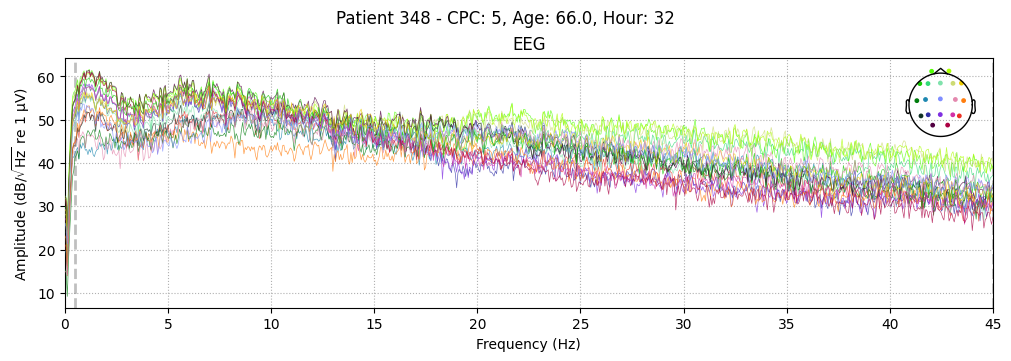

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


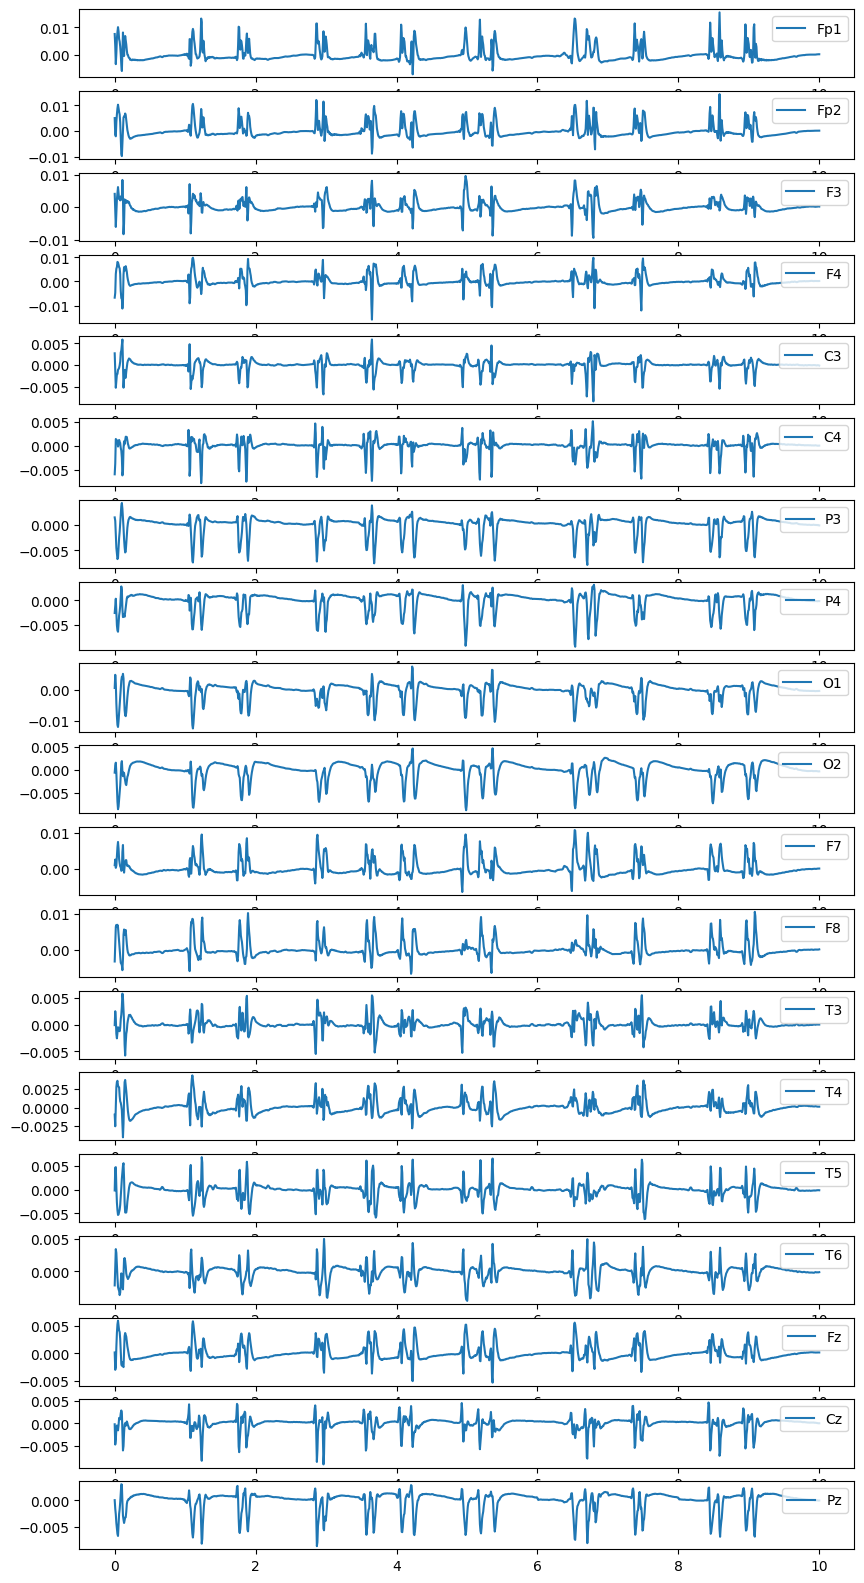

Sampling frequency of the instance is already 128.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 16.000 (s)


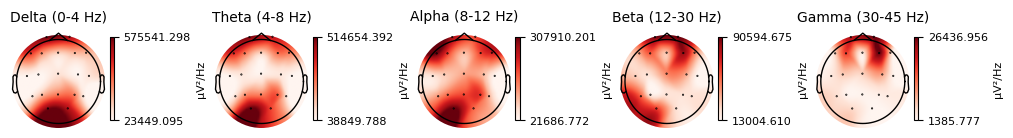

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 16.000 (s)
Plotting amplitude spectral density (dB=True).


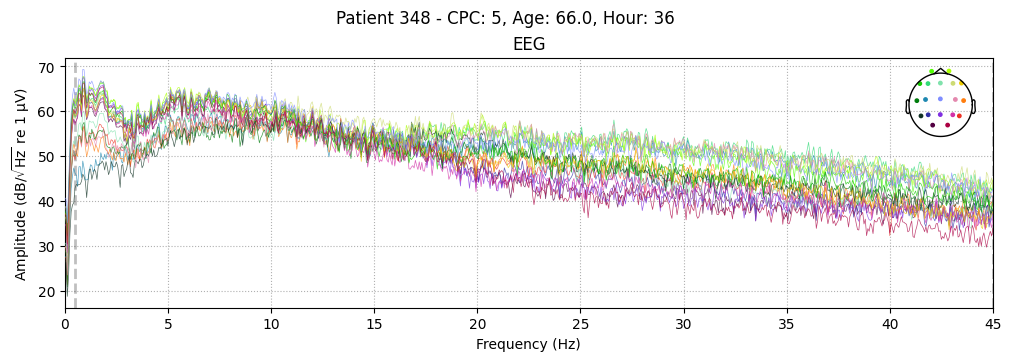

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


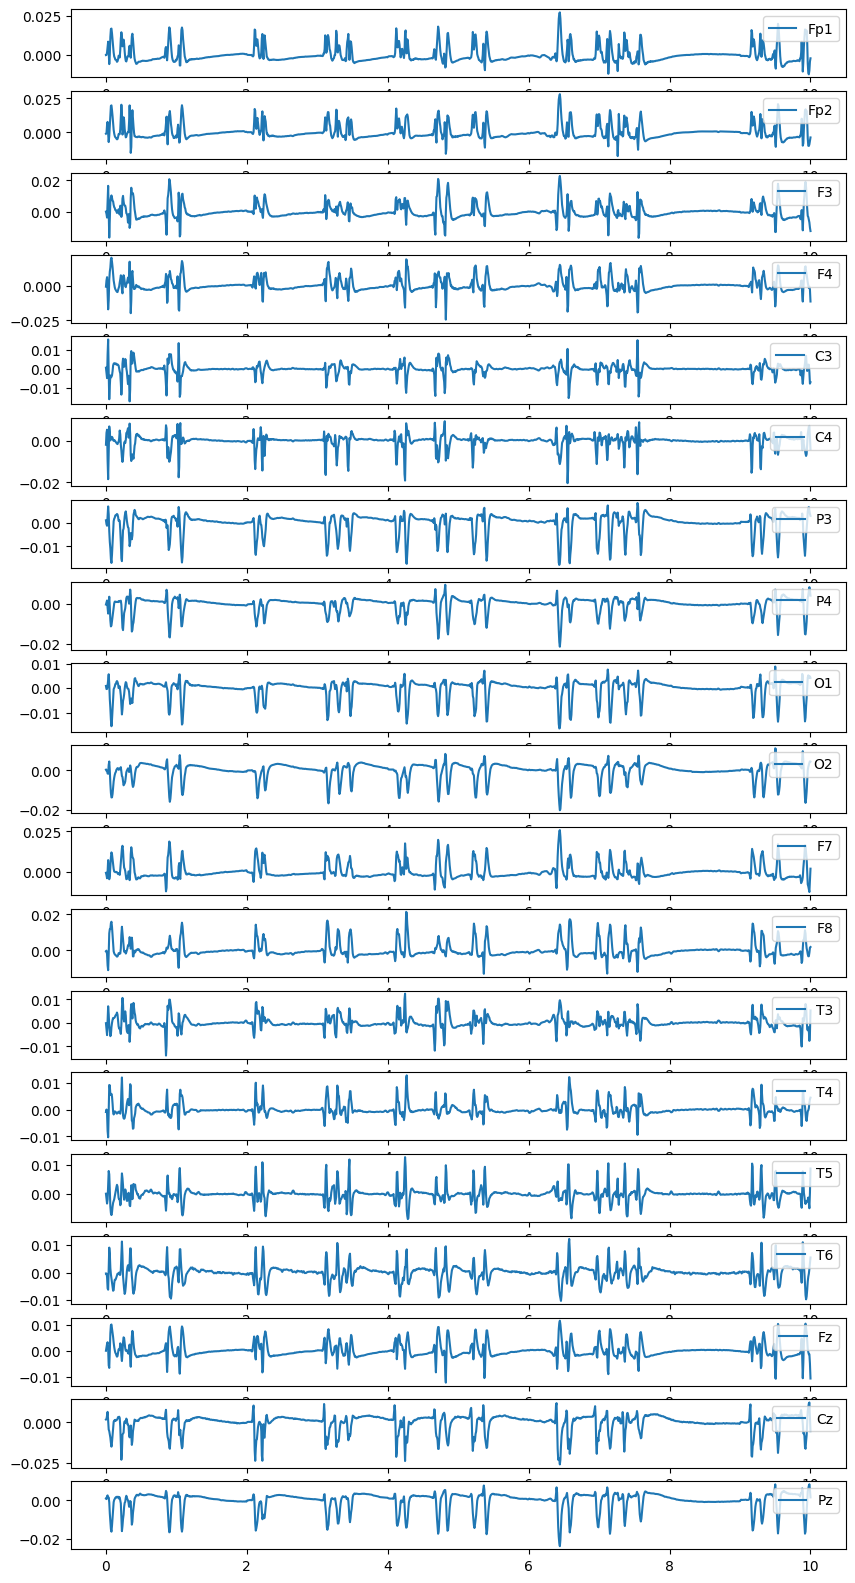

Sampling frequency of the instance is already 128.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 16.000 (s)


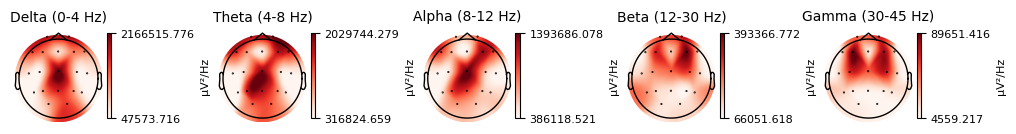

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 16.000 (s)
Plotting amplitude spectral density (dB=True).


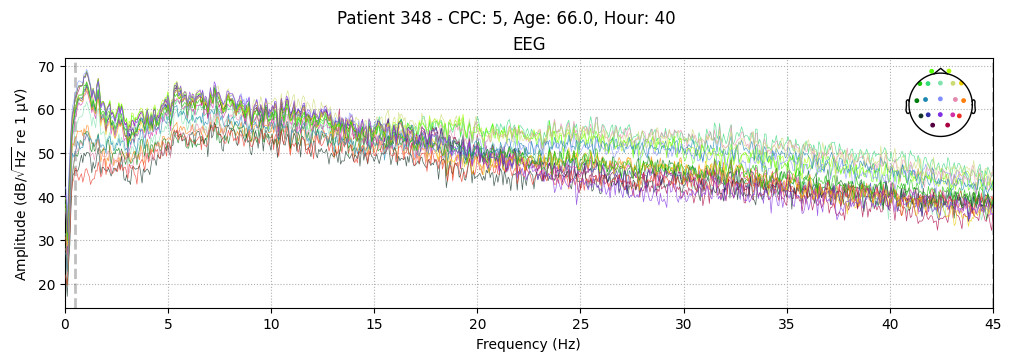

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


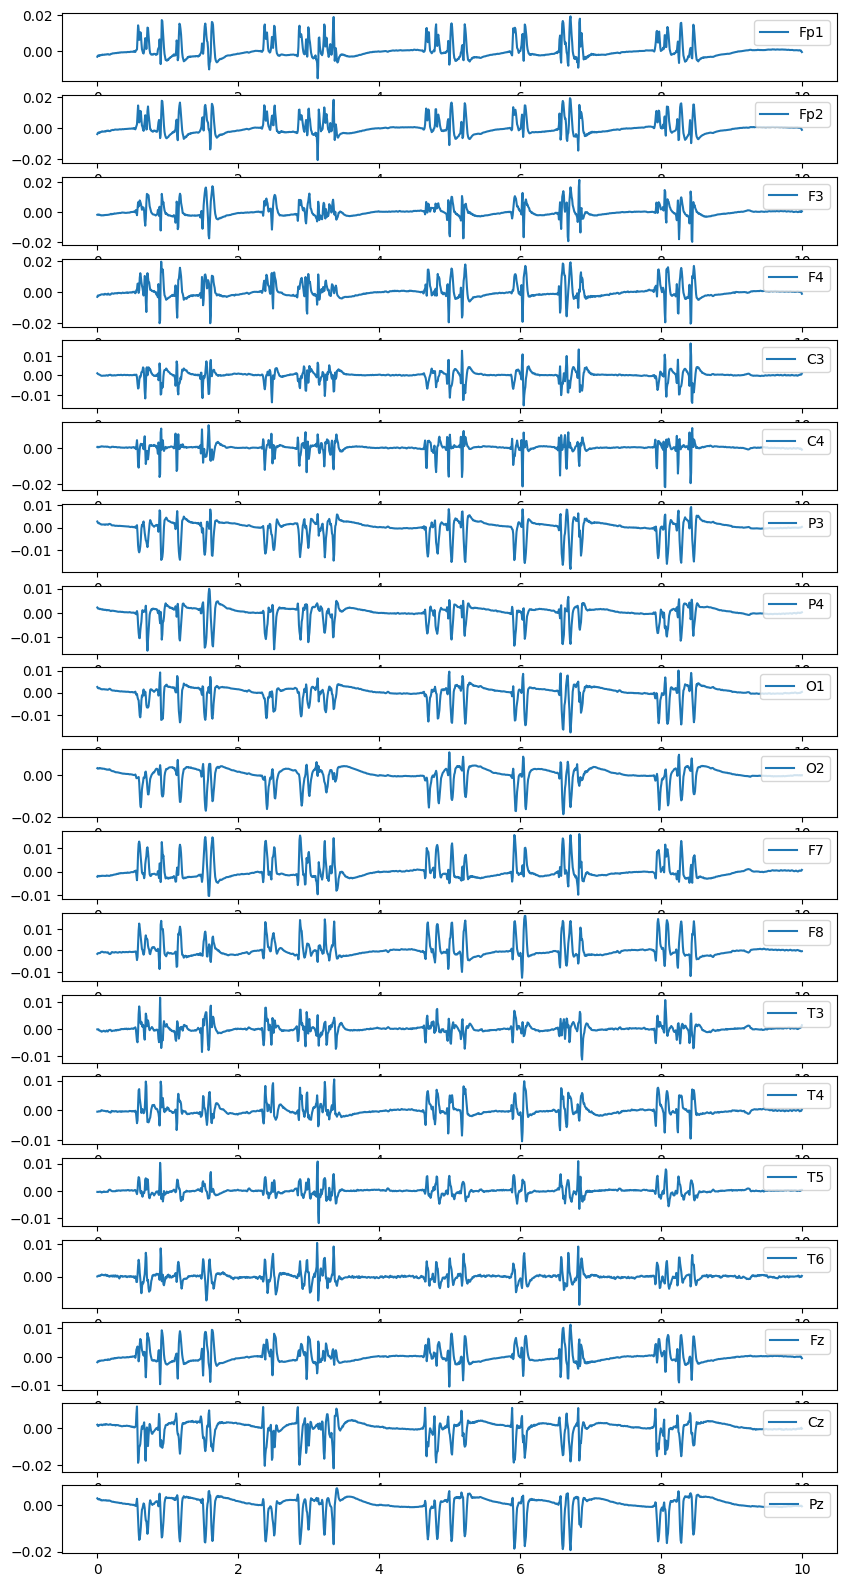

Sampling frequency of the instance is already 128.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 16.000 (s)


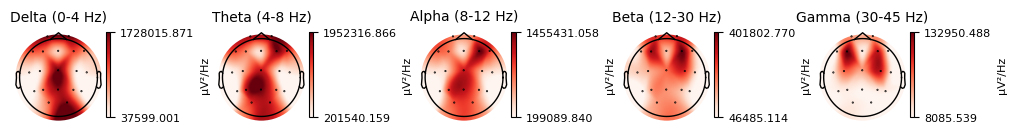

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 16.000 (s)
Plotting amplitude spectral density (dB=True).


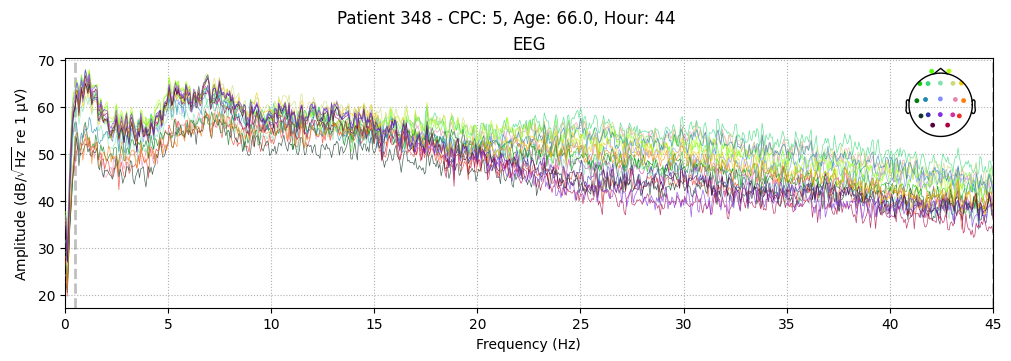

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


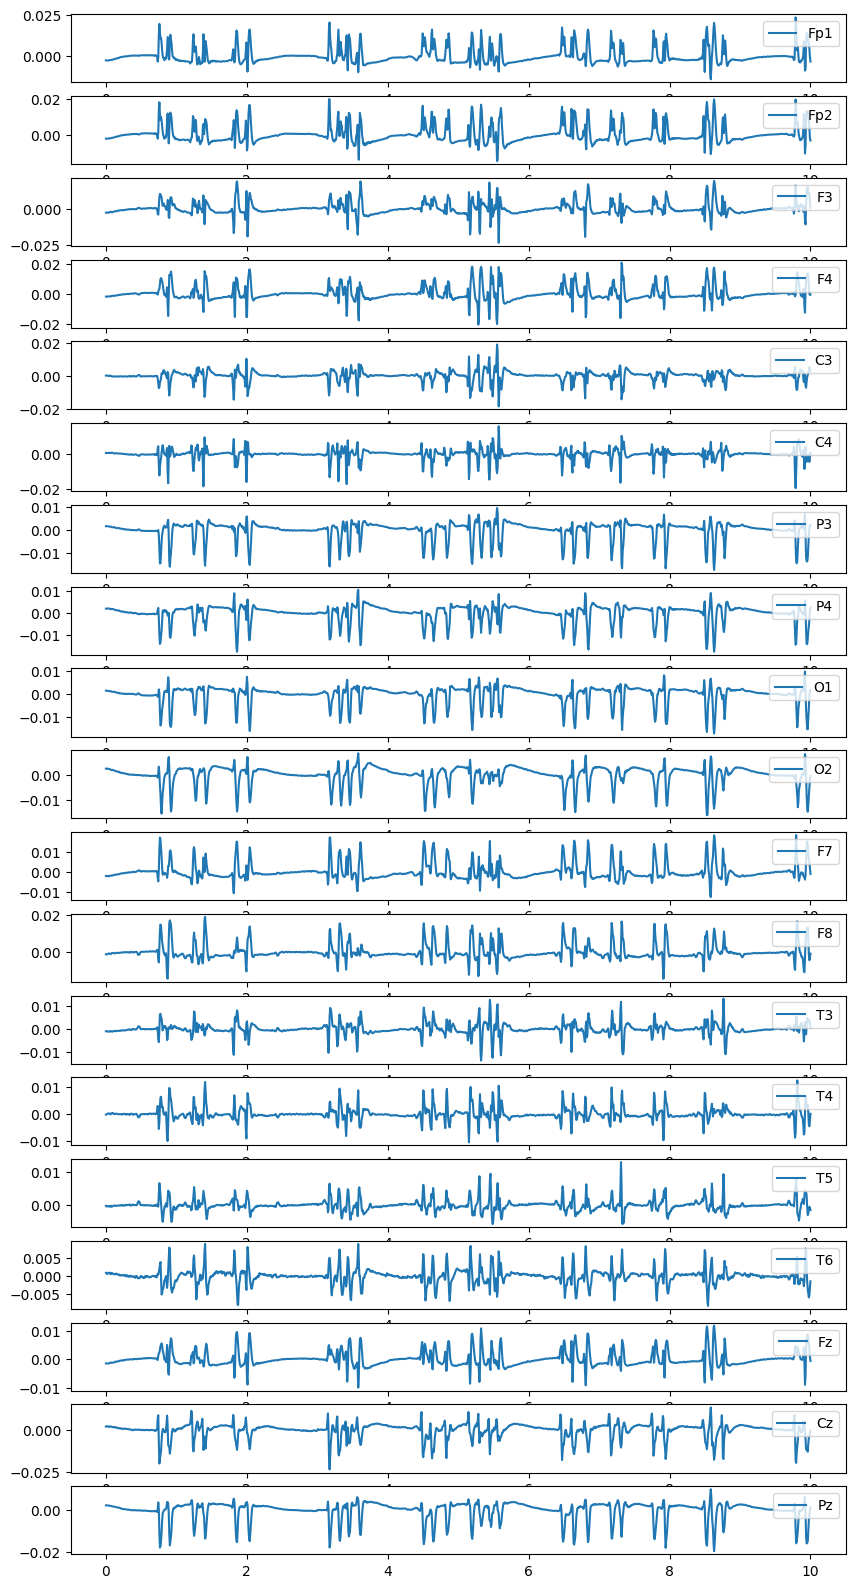

Sampling frequency of the instance is already 128.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 16.000 (s)


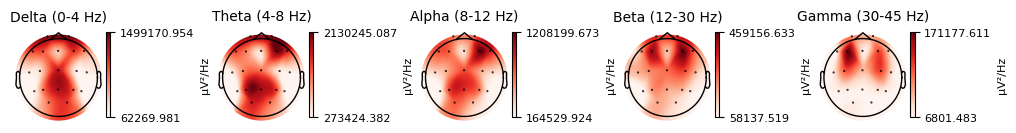

,Id_Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC,numeric_outcome,Hour
18,348,E,66.0,Male,5.0,True,True,33.0,Poor,5,0,32
470,348,E,66.0,Male,5.0,True,True,33.0,Poor,5,0,36
896,348,E,66.0,Male,5.0,True,True,33.0,Poor,5,0,40
1309,348,E,66.0,Male,5.0,True,True,33.0,Poor,5,0,44


In [115]:
# Poor
pat_num=2
cpc=df_poor[df_poor["Id_Patient"]==int(patients_poor[pat_num])]["CPC"].values
ind=df_poor[df_poor["Id_Patient"]==int(patients_poor[pat_num])].index
age=df_poor[df_poor["Id_Patient"]==int(patients_poor[pat_num])]["Age"].values
hour=df_poor[df_poor["Id_Patient"]==int(patients_poor[pat_num])]["Hour"].values
for k ,i in enumerate(ind):
    raw=Raws[i].copy()
    #raw= mne.set_bipolar_reference(Raws[i], anode=ANODE, cathode=CATHODE, ch_name=CH_NAMES, drop_refs=False).copy()
    # Raws[i].set_montage("standard_1020", on_missing="ignore")
    raw.pick_types(eeg=True)
    fig= mne.viz.plot_raw_psd(raw, fmax=45, show=False, picks=channels, estimate="amplitude")
    fig.suptitle(
        f"Patient {patients_poor[pat_num]} - CPC: {cpc[0]}, Age: {age[0]}, Hour: {hour[k]}",
        ha='center'
    )
    
    plt.show()
    time=10
    aux_raw=pd.DataFrame(raw.pick_channels(channels).get_data()[:,:128*time].T,columns=channels)
    _, ax=plt.subplots(nrows=len(channels), figsize=(10, 20))
    t=np.linspace(0, time, 128*time)
    for k, r in enumerate(channels): 
        ax[k].plot(t, aux_raw[r], label=r)
        ax[k].legend(loc="upper right")
    plt.show()
    
    
    raw.resample(128).pick_channels(channels).plot_psd_topomap()
    plt.show()
    
    

df_poor[df_poor["Id_Patient"]==int(patients_poor[pat_num])]

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


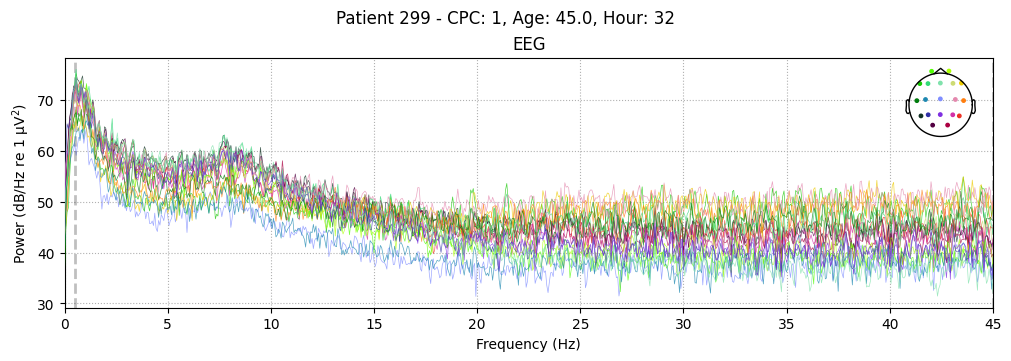

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


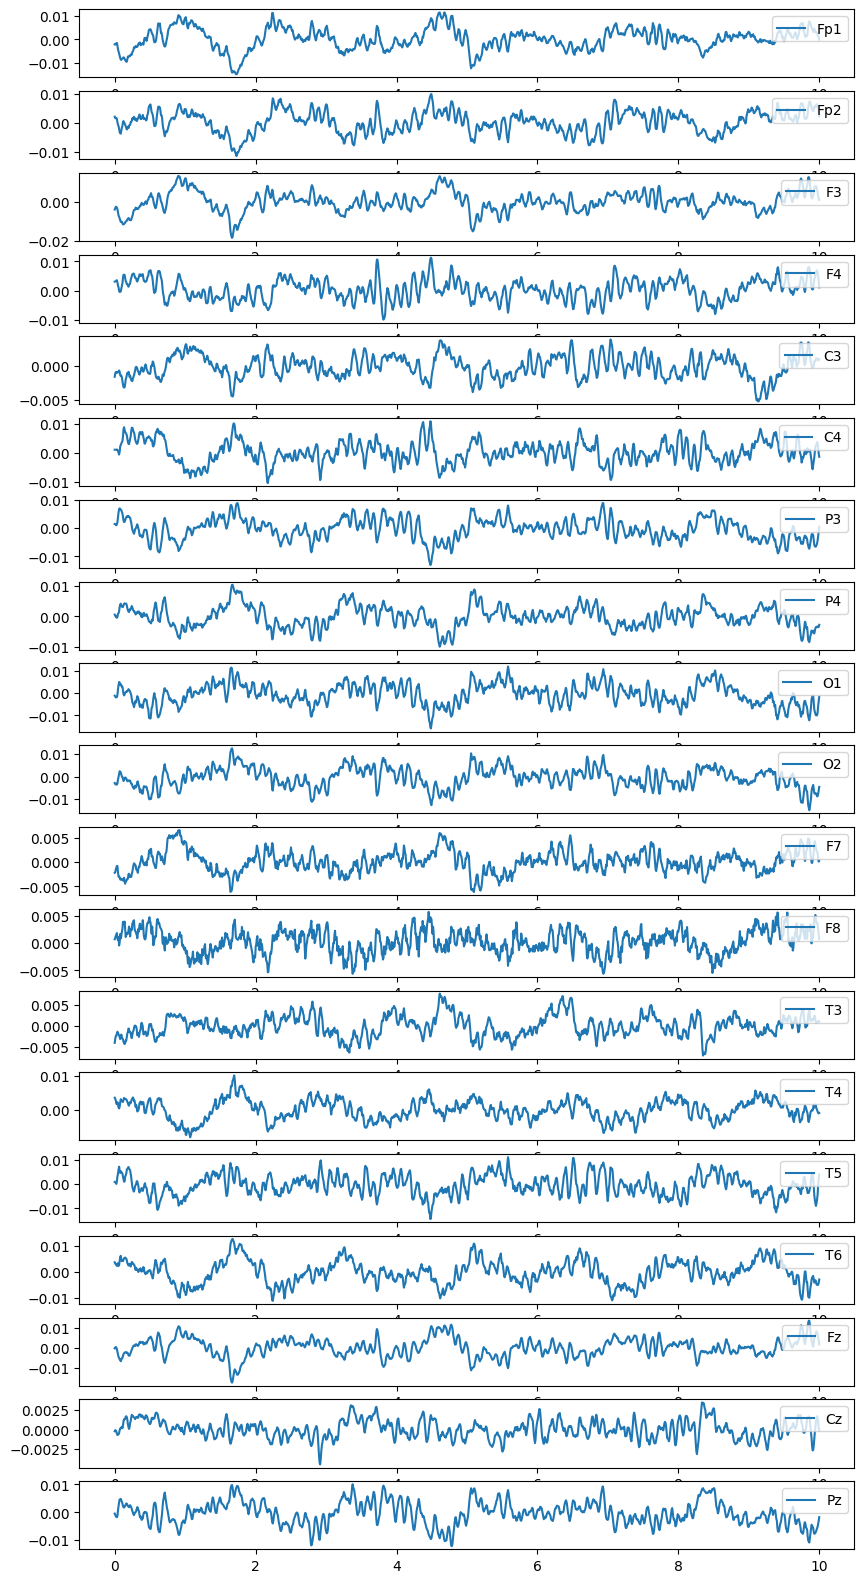

Sampling frequency of the instance is already 128.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 16.000 (s)


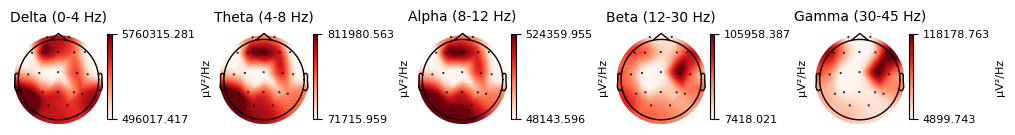

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


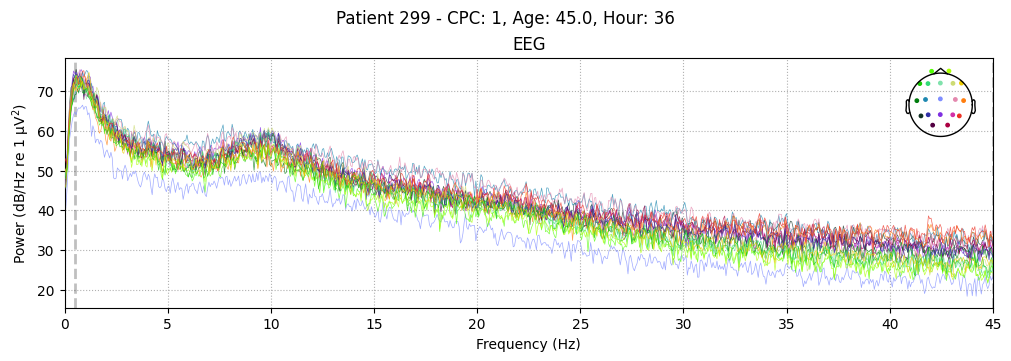

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


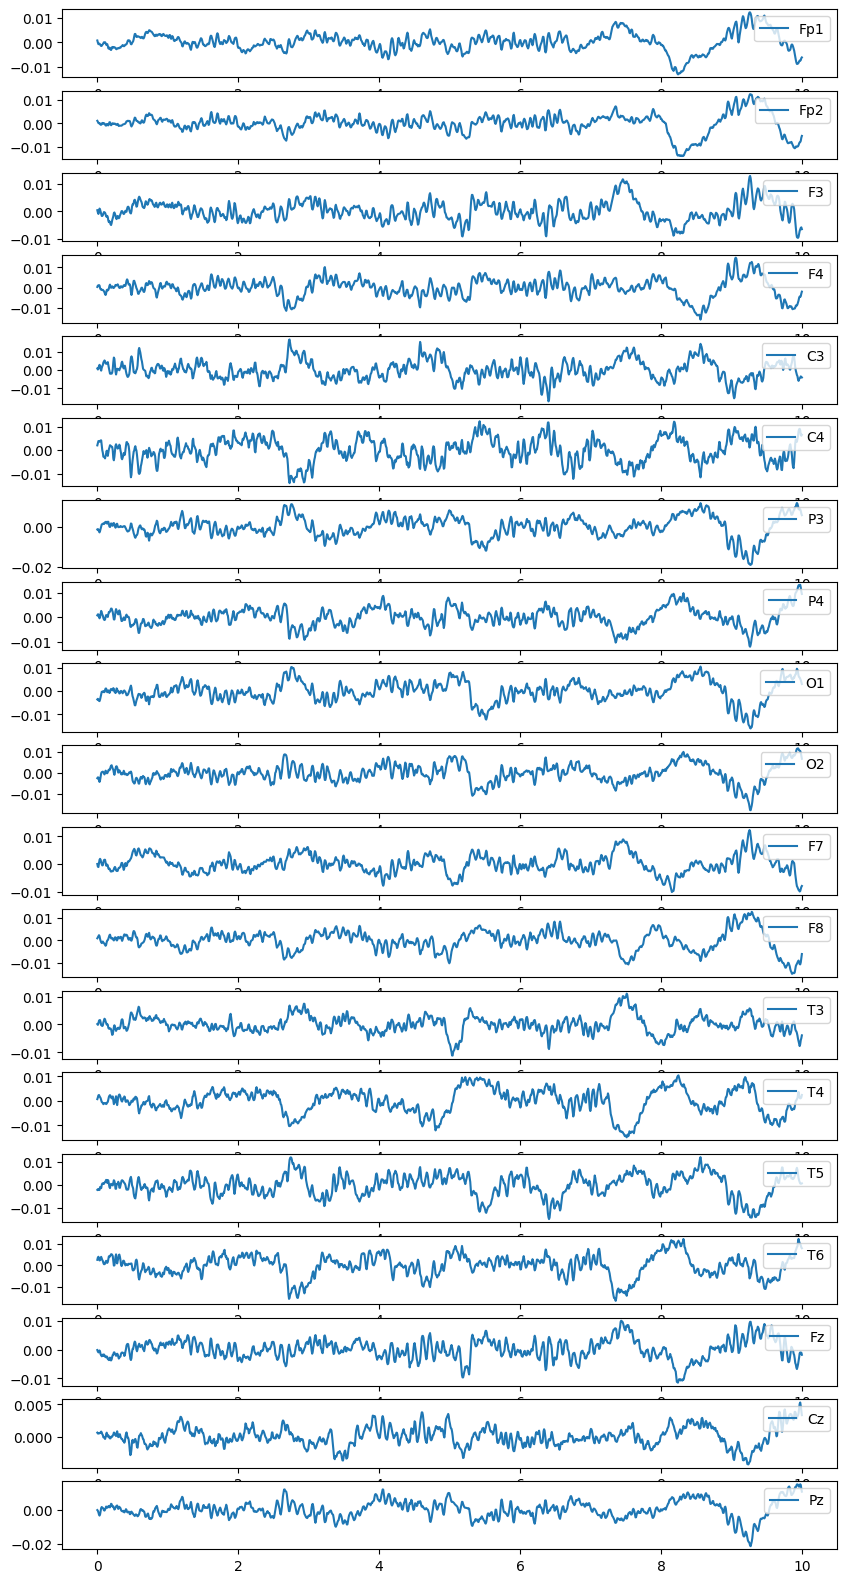

Sampling frequency of the instance is already 128.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 16.000 (s)


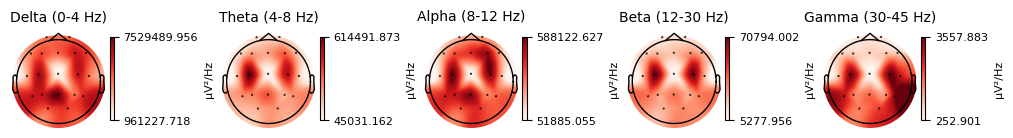

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


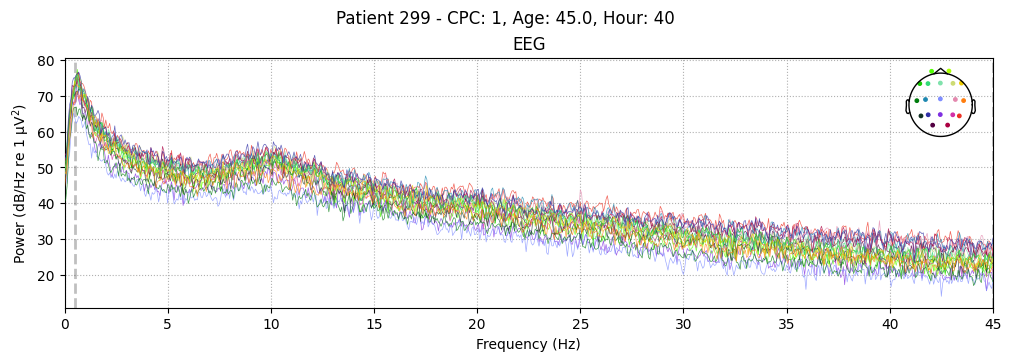

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


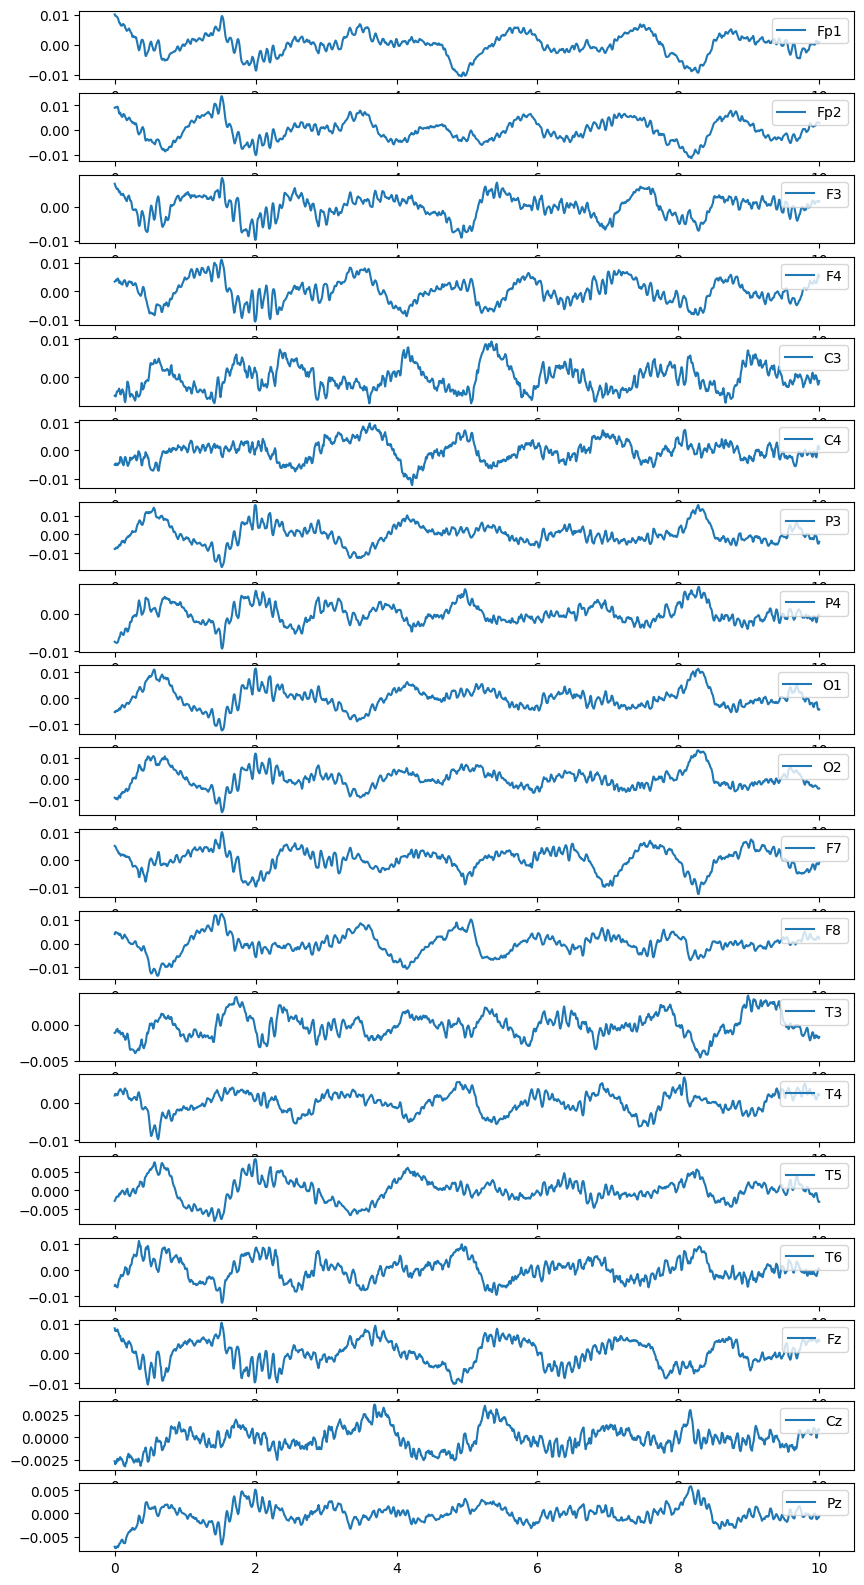

Sampling frequency of the instance is already 128.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 16.000 (s)


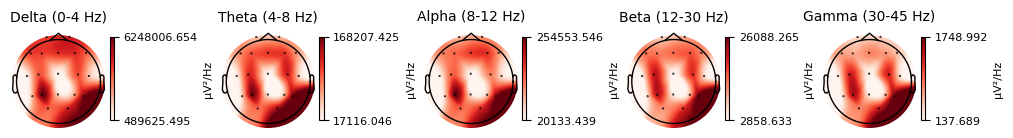

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


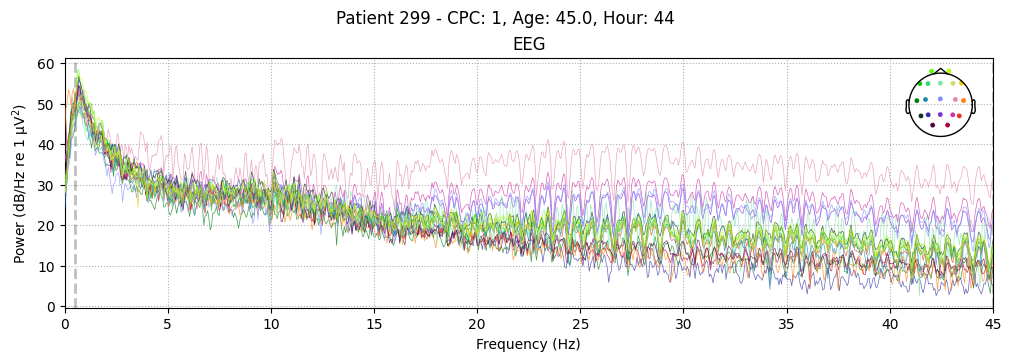

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


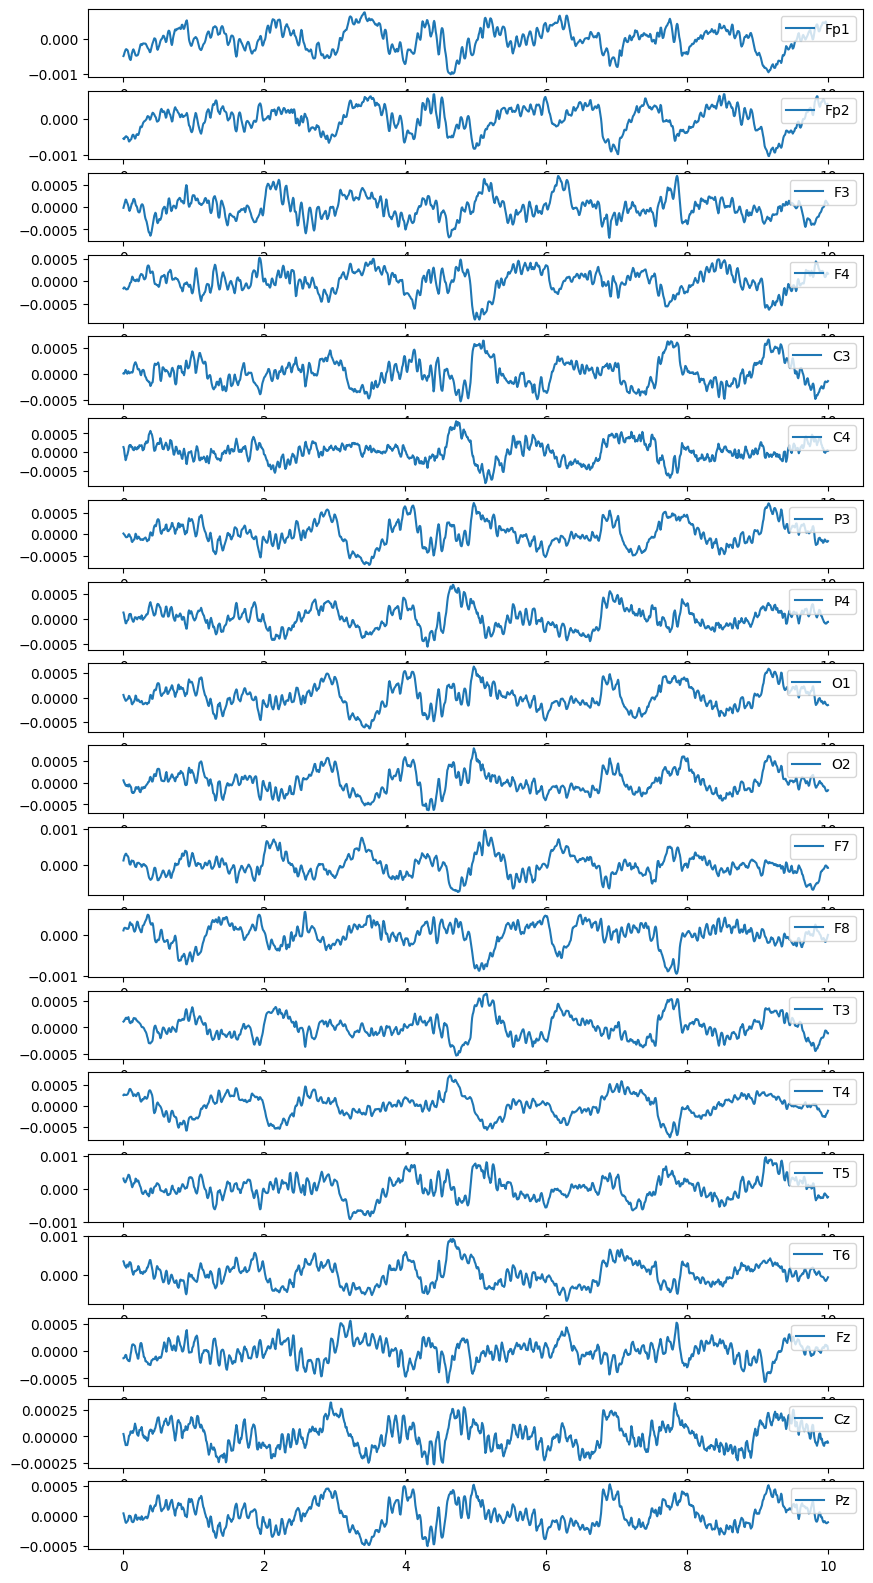

Sampling frequency of the instance is already 128.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 16.000 (s)


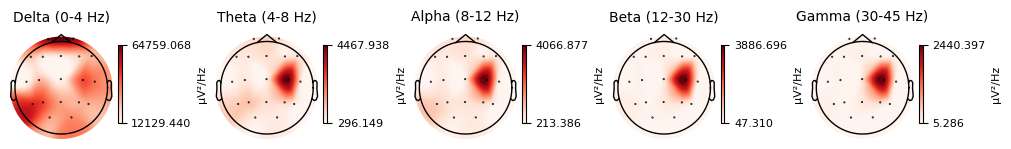

,Id_Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC,numeric_outcome,Hour
2,299,A,45.0,Male,NaN,True,True,33.0,Good,1,1,32
454,299,A,45.0,Male,NaN,True,True,33.0,Good,1,1,36
881,299,A,45.0,Male,NaN,True,True,33.0,Good,1,1,40
1297,299,A,45.0,Male,NaN,True,True,33.0,Good,1,1,44


In [114]:
# Good
pat_num=2
cpc=df_good[df_good["Id_Patient"]==int(patients_good[pat_num])]["CPC"].values
ind=df_good[df_good["Id_Patient"]==int(patients_good[pat_num])].index
age=df_good[df_good["Id_Patient"]==int(patients_good[pat_num])]["Age"].values
hour=df_good[df_good["Id_Patient"]==int(patients_good[pat_num])]["Hour"].values
for k ,i in enumerate(ind):
    raw=Raws[i].copy()
    #raw= mne.set_bipolar_reference(Raws[i], anode=ANODE, cathode=CATHODE, ch_name=CH_NAMES, drop_refs=False).copy()
    # Raws[i].set_montage("standard_1020", on_missing="ignore")
    raw.pick_types(eeg=True)
    fig= mne.viz.plot_raw_psd(raw, fmax=45, show=False, picks=channels)
    fig.suptitle(
        f"Patient {patients_good[pat_num]} - CPC: {cpc[0]}, Age: {age[0]}, Hour: {hour[k]}",
        ha='center'
    )
    
    plt.show()
    time=10
    aux_raw=pd.DataFrame(raw.pick_channels(channels).get_data()[:,:128*time].T,columns=channels)
    _, ax=plt.subplots(nrows=len(channels), figsize=(10, 20))
    t=np.linspace(0, time, 128*time)
    for k, r in enumerate(channels): 
        ax[k].plot(t, aux_raw[r], label=r)
        ax[k].legend(loc="upper right")
    plt.show()
    
    raw.resample(128).pick_channels(channels).plot_psd_topomap()
    plt.show()

df_good[df_good["Id_Patient"]==int(patients_good[pat_num])]